#### UČITAVANJE PAKETA I PODATAKA

In [364]:
import os
import copy
import numpy as np
from numpy import random
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from PIL import Image

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.manifold import TSNE

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

from torch.utils.data import DataLoader, Dataset, random_split, Subset
from torchvision import datasets, transforms

In [365]:
base_dir = Path("../data/tomatoleaf/tomato")

train_dir = base_dir / "train"
test_dir = base_dir / "val"

# Ovaj deo koda nam služi samo za proveru
#print("Train dir:", train_dir.resolve())
#print("Test dir:", test_dir.resolve())

print("Train exists:", train_dir.exists())
print("Test exists:", test_dir.exists())

IMG_SIZE = 64  # pokušale smo sa 128 i 224, ali je izvršavanje bilo presporo
BATCH_SIZE = 32  # pokušale smo sa 64, ali smo dobile gore rezultate
DROPOUT_RATE = 0.3
VALIDATION_SIZE = 0.2
SEED = 42
EMBEDDING_DIM = 64  # sa 32 i 128 smo dobile gori rezultat

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Train exists: True
Test exists: True
Device: cpu


In [366]:
def add_windows_long_path_prefix(path):
    """
    Na Windowsu neki fajlovi iz ovog dataset-a imaju jako duga imena.
    Ako je apsolutna putanja duža od Windows MAX_PATH ograničenja, open() moze da prijavi
    FileNotFoundError iako fajl stvarno postoji. Prefiks \\?\ omogucava citanje dugih putanja.
    Na Linuxu/macOS-u funkcija samo vraca obicnu putanju.
    """
    path = Path(path).resolve()
    path_str = str(path)

    if os.name == "nt":
        if path_str.startswith("\\\\"):
            return "\\\\?\\UNC\\" + path_str.lstrip("\\")
        return "\\\\?\\" + path_str

    return path_str


def pil_loader_safe(path):
    """
    Loader za torchvision ImageFolder.
    Koristi Windows long-path prefiks i konvertuje sve slike u RGB.
    """
    with open(add_windows_long_path_prefix(path), "rb") as f:
        image = Image.open(f)
        return image.convert("RGB")


In [367]:
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2,
        hue=0.05
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [368]:
train_val_dataset_train = datasets.ImageFolder(
    root=str(train_dir),
    transform=train_transform,
    loader=pil_loader_safe
)

train_val_dataset_val = datasets.ImageFolder(
    root=str(train_dir),
    transform=val_test_transform,
    loader=pil_loader_safe
)

test_dataset = datasets.ImageFolder(
    root=str(test_dir),
    transform=val_test_transform,
    loader=pil_loader_safe
)

class_names = train_val_dataset_train.classes
num_classes = len(class_names)

print("Klase:", class_names)
print("Broj klasa:", num_classes)
print("Broj slika u originalnom train skupu:", len(train_val_dataset_train))
print("Broj slika u test skupu:", len(test_dataset))

Klase: ['Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___Leaf_Mold', 'Tomato___Septoria_leaf_spot', 'Tomato___Spider_mites Two-spotted_spider_mite', 'Tomato___Target_Spot', 'Tomato___Tomato_Yellow_Leaf_Curl_Virus', 'Tomato___Tomato_mosaic_virus', 'Tomato___healthy']
Broj klasa: 10
Broj slika u originalnom train skupu: 10000
Broj slika u test skupu: 1000


#### PODELA NA TRAIN/VAL/TEST SKUPOVE I LOADER-E

In [369]:
val_size = int(len(train_val_dataset_train) * VALIDATION_SIZE)
train_size = len(train_val_dataset_train) - val_size

generator = torch.Generator().manual_seed(SEED)

indices = torch.randperm(len(train_val_dataset_train), generator=generator)

train_indices = indices[:train_size]
val_indices = indices[train_size:]

In [370]:
train_dataset = Subset(train_val_dataset_train, train_indices)
val_dataset = Subset(train_val_dataset_val, val_indices)

print("Train size:", len(train_dataset))
print("Validation size:", len(val_dataset))
print("Test size:", len(test_dataset))

Train size: 8000
Validation size: 2000
Test size: 1000


In [371]:
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

#### DEFINISANJE KLASA

In [372]:
class TripletDataset(Dataset):
    def __init__(self, subset_dataset, transform=None):
        self.dataset = subset_dataset
        self.transform = transform

        # originalni dataset (ImageFolder)
        base_dataset = self.dataset.dataset

        self.class_to_indices = {}

        # samo indeksi iz SUBSET-a
        for subset_idx in range(len(self.dataset)):
            _, label = self.dataset[subset_idx]

            if label not in self.class_to_indices:
                self.class_to_indices[label] = []
            self.class_to_indices[label].append(subset_idx)

        self.labels = list(self.class_to_indices.keys())

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        anchor_img, anchor_label = self.dataset[idx]

        # positive
        positive_idx = idx
        while positive_idx == idx:
            positive_idx = random.choice(self.class_to_indices[anchor_label])

        positive_img, _ = self.dataset[positive_idx]

        # negative
        negative_label = random.choice([l for l in self.labels if l != anchor_label])
        negative_idx = random.choice(self.class_to_indices[negative_label])

        negative_img, _ = self.dataset[negative_idx]

        return anchor_img, positive_img, negative_img, anchor_label

In [373]:
train_triplet_dataset = TripletDataset(train_dataset, transform=None)
val_triplet_dataset = TripletDataset(val_dataset, transform=None)

In [374]:
len(train_triplet_dataset)

8000

In [375]:
class EmbeddingCNN(nn.Module):
    def __init__(self, embedding_dim=128):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, 2, 1),
            nn.BatchNorm2d(32),
            nn.ReLU(),

            nn.Conv2d(32, 64, 3, 2, 1),
            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.Conv2d(64, 128, 3, 2, 1),
            nn.BatchNorm2d(128),
            nn.ReLU(),

            nn.Conv2d(128, 256, 3, 2, 1),
            nn.BatchNorm2d(256),
            nn.ReLU(),

            nn.Conv2d(256, 256, 3, 2, 1),
            nn.BatchNorm2d(256),
            nn.ReLU(),

            nn.AdaptiveAvgPool2d((1, 1))
        )

        self.embedding = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 512),
            nn.ReLU(),
            nn.Dropout(p=DROPOUT_RATE),
            nn.Linear(512, embedding_dim)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.embedding(x)
        x = F.normalize(x, p=2, dim=1)
        return x

#### TRENIRANJE MODELA I GRAFIČKI PRIKAZ TOKA TRENINGA

Kod metric learning-a nema smisla pratiti tačnost tokom treninga, jer CNN uči embeddinge, a ne direktno klase. Zato ćemo tokom treninga pratiti samo train_loss i val_loss, a klasifikacione metrike ćemo računati kod KNN modela kasnije.

In [377]:
EPOCHS = 20
LEARNING_RATE = 0.0001
MARGIN = 0.5

model = EmbeddingCNN(embedding_dim=EMBEDDING_DIM)
model = model.to(device)

criterion = nn.TripletMarginLoss(margin=MARGIN, p=2)  
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

train_loader = DataLoader(train_triplet_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_triplet_dataset, batch_size=BATCH_SIZE, shuffle=False)

metrics = {
    "train_loss": [],
    "train_steps": [],
    "val_loss": [],
    "val_steps": [],
}

training_step = 0
best_val_loss = float("inf")

for epoch in range(EPOCHS):

    model.train()
    
    for anchor, positive, negative, _ in train_loader:

        anchor = anchor.to(device)
        positive = positive.to(device)
        negative = negative.to(device)

        optimizer.zero_grad()

        a = model(anchor)
        p = model(positive)
        n = model(negative)

        loss = criterion(a, p, n)

        loss.backward()
        optimizer.step()

        train_loss = loss.item()
        metrics["train_loss"].append(train_loss)
        metrics["train_steps"].append(training_step)
        training_step += 1

    model.eval()

    total_val_loss = 0
    val_samples = 0

    with torch.no_grad():

        for anchor, positive, negative, _ in val_loader:

            anchor = anchor.to(device)
            positive = positive.to(device)
            negative = negative.to(device)

            a = model(anchor)
            p = model(positive)
            n = model(negative)

            loss = F.triplet_margin_loss(
                a, p, n,
                margin=MARGIN,
                p=2,
                reduction="sum"
            )

            total_val_loss += loss.item()
            val_samples += anchor.size(0)

    val_loss = total_val_loss / val_samples

    metrics["val_loss"].append(val_loss)
    metrics["val_steps"].append(training_step)
    

    if val_loss < best_val_loss:
        best_val_loss = val_loss

        torch.save(
            model.state_dict(),
            "best_embedding_cnn_triplet.pth"
        )

    print(
        f"Epoch {epoch+1}/{EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Validation Loss: {val_loss:.4f}"
    )


print("\nBest Validation Loss:", best_val_loss)

Epoch 1/20 | Train Loss: 0.1941 | Validation Loss: 0.2297
Epoch 2/20 | Train Loss: 0.2028 | Validation Loss: 0.1951
Epoch 3/20 | Train Loss: 0.2237 | Validation Loss: 0.1688
Epoch 4/20 | Train Loss: 0.1494 | Validation Loss: 0.1470
Epoch 5/20 | Train Loss: 0.1586 | Validation Loss: 0.1432
Epoch 6/20 | Train Loss: 0.1939 | Validation Loss: 0.1203
Epoch 7/20 | Train Loss: 0.1421 | Validation Loss: 0.1101
Epoch 8/20 | Train Loss: 0.1336 | Validation Loss: 0.0965
Epoch 9/20 | Train Loss: 0.2127 | Validation Loss: 0.0826
Epoch 10/20 | Train Loss: 0.2008 | Validation Loss: 0.0811
Epoch 11/20 | Train Loss: 0.0738 | Validation Loss: 0.0866
Epoch 12/20 | Train Loss: 0.0791 | Validation Loss: 0.0772
Epoch 13/20 | Train Loss: 0.1211 | Validation Loss: 0.0723
Epoch 14/20 | Train Loss: 0.1605 | Validation Loss: 0.0665
Epoch 15/20 | Train Loss: 0.0590 | Validation Loss: 0.0627
Epoch 16/20 | Train Loss: 0.0538 | Validation Loss: 0.0619
Epoch 17/20 | Train Loss: 0.0541 | Validation Loss: 0.0576
Epoch 

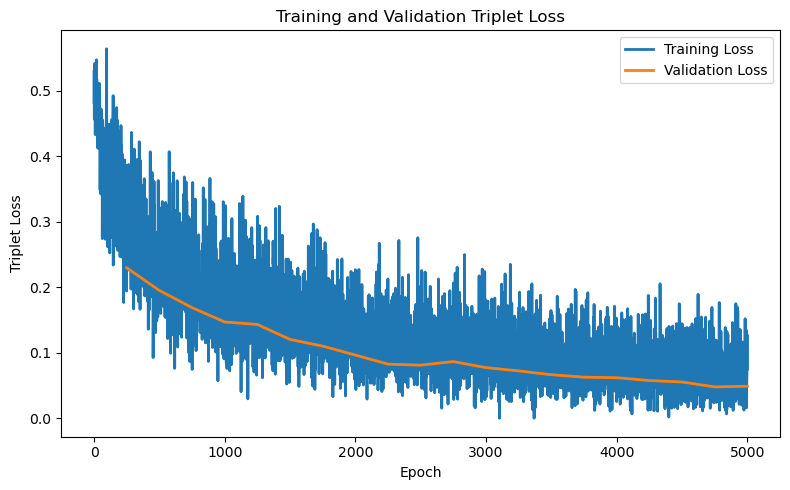

In [378]:
plt.figure(figsize=(8, 5))

plt.title('Training and Validation Triplet Loss')
plt.xlabel('Epoch')
plt.ylabel('Triplet Loss')

plt.plot(metrics['train_steps'], metrics['train_loss'], linewidth=2, label='Training Loss')
plt.plot(metrics['val_steps'], metrics['val_loss'], linewidth=2, label='Validation Loss')

plt.legend()

plt.tight_layout()
plt.show()

#### EKSTRAKCIJA EMBEDDING-A

In [379]:
def extract_embeddings(model, loader, device):
    model.eval()

    embeddings = []
    labels = []

    with torch.no_grad():
        for anchor, positive, negative, label in loader:
            anchor = anchor.to(device)

            emb = model(anchor)   # koristi anchor kao reprezentaciju

            embeddings.append(emb.cpu().numpy())
            labels.append(label.numpy())

    embeddings = np.vstack(embeddings)
    labels = np.concatenate(labels)

    return embeddings, labels

Test dataset ne treba da vraća triplete, jer to nema smisla za evaluaciju.

Naime, u treningu i validaciji koristimo triplete i kao izlaz CNN-a dobijamo embedding-e (umesto klase kod običnog CNN-a), odnosno nove reprezentacije slika, a pri 
evaluaciji modela koristimo normalne slike, odnosno koristimo njihovu standardnu reprezentaciju, pa ćemo napraviti i funkciju koja
ekstraktuje takve slike.

In [380]:
def extract_embeddings_standard(model, loader, device):
    model.eval()

    embeddings = []
    labels = []

    with torch.no_grad():
        for images, label in loader:
            images = images.to(device)

            emb = model(images)

            embeddings.append(emb.cpu().numpy())
            labels.append(label.numpy())

    embeddings = np.vstack(embeddings)
    labels = np.concatenate(labels)

    return embeddings, labels

In [381]:
train_emb, train_labels = extract_embeddings(model, train_loader, device)
val_emb, val_labels = extract_embeddings(model, val_loader, device)
test_emb, test_labels = extract_embeddings_standard(model, test_loader, device)

In [382]:
train_emb.shape, train_labels.shape

((8000, 64), (8000,))

In [383]:
val_emb.shape, val_labels.shape

((2000, 64), (2000,))

In [384]:
test_emb.shape, test_labels.shape

((1000, 64), (1000,))

#### KNN MODEL

Sada ćemo ispitivati različite vrednosti za hiperparametar k kod knn modela i birati onu vrednost za koju se dobija najbolja tačnost na validacionom skupu.

Na osnovu te tačnosti gledamo koliko su nam dobri embedding-i i da li ima potrebe da menjamo neke parametre kod CNN i triplet loss-a.

Kako su embedding vektori već L2 normalizovani (svaki embedding ima normu 1), nema potrebe da ih standardizujemo jer bi to promenilo geometriju prostora koji je CNN naučio, a to nije poželjno za metric learning.

Kod metric learning-a upravo želimo da KNN radi u tom naučenom embedding prostoru.

In [385]:
k_values = [1, 3, 5, 7, 9, 11, 15]

results = {}

for k in k_values:
    knn = KNeighborsClassifier(
        n_neighbors=k,
        weights="distance",
        metric="euclidean"
    )

    # treniranje KNN-a na train embeddingima
    knn.fit(train_emb, train_labels)

    # evaluacija na validation skupu
    val_predictions = knn.predict(val_emb)

    val_accuracy = accuracy_score(val_labels, val_predictions)

    results[k] = val_accuracy

    print(f"k={k} | Validation Accuracy: {val_accuracy:.4f}")


best_k = max(results, key=results.get)

print("\nBest k:", best_k)
print("Best Validation Accuracy:", results[best_k])

k=1 | Validation Accuracy: 0.8595
k=3 | Validation Accuracy: 0.8765
k=5 | Validation Accuracy: 0.8890
k=7 | Validation Accuracy: 0.8850
k=9 | Validation Accuracy: 0.8885
k=11 | Validation Accuracy: 0.8855
k=15 | Validation Accuracy: 0.8860

Best k: 5
Best Validation Accuracy: 0.889


#### EVALUACIJA NAJBOLJEG MODELA NA TEST SKUPU

In [386]:
test_pred = knn.predict(test_emb)
test_acc = accuracy_score(test_labels, test_pred)
print("Test Accuracy:", test_acc)

Test Accuracy: 0.862


In [387]:
print("\nClassification Report (Test):")
print(classification_report(test_labels, test_pred, target_names=class_names))


Classification Report (Test):
                                               precision    recall  f1-score   support

                      Tomato___Bacterial_spot       0.91      0.92      0.92       100
                        Tomato___Early_blight       0.79      0.80      0.80       100
                         Tomato___Late_blight       0.89      0.82      0.85       100
                           Tomato___Leaf_Mold       0.75      0.83      0.79       100
                  Tomato___Septoria_leaf_spot       0.76      0.84      0.80       100
Tomato___Spider_mites Two-spotted_spider_mite       0.91      0.87      0.89       100
                         Tomato___Target_Spot       0.85      0.78      0.81       100
       Tomato___Tomato_Yellow_Leaf_Curl_Virus       0.92      0.91      0.91       100
                 Tomato___Tomato_mosaic_virus       0.88      1.00      0.94       100
                             Tomato___healthy       1.00      0.85      0.92       100

          

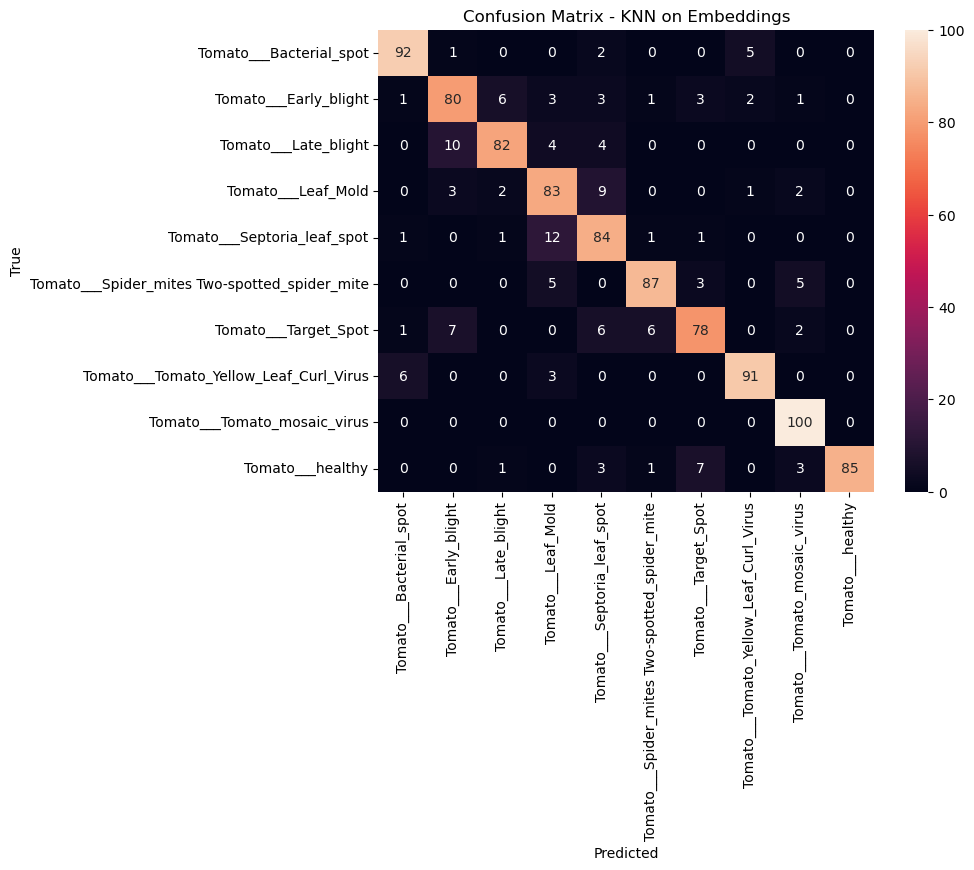

In [388]:
cm = confusion_matrix(test_labels, test_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d',  xticklabels=class_names, yticklabels=class_names)
plt.title("Confusion Matrix - KNN on Embeddings")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

#### VIZUELIZACIJA POMOĆU t-SNE

In [389]:
tsne = TSNE(n_components=2, perplexity=30, random_state=SEED)
emb_2d = tsne.fit_transform(test_emb)

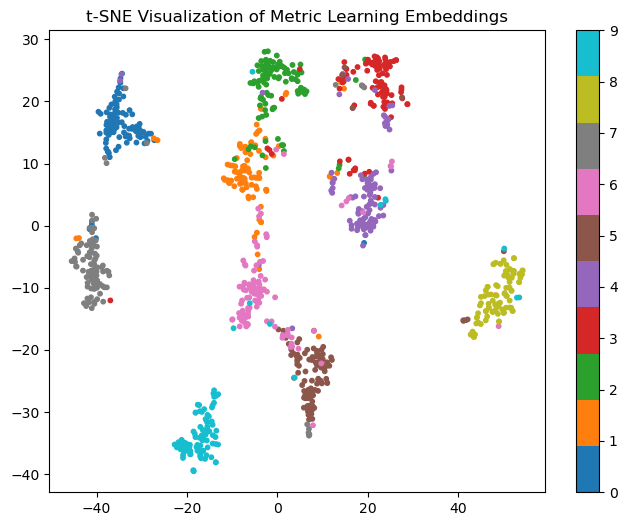

In [390]:
plt.figure(figsize=(8,6))
plt.scatter(emb_2d[:,0], emb_2d[:,1], c=test_labels, cmap='tab10', s=10)
plt.title("t-SNE Visualization of Metric Learning Embeddings")
plt.colorbar()
plt.show()